<a href="https://colab.research.google.com/github/ibrahim2230/audio-digit-classification/blob/main/EE413_DFT_Part.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Frequency-Domain Feature Extraction (DFT-Based Analysis)

This section describes the methods used to analyze audio signals in the frequency domain using the Discrete Fourier Transform (DFT). The goal is to extract meaningful spectral features that can be used for classification.

 1. Audio Loading and Preprocessing

Each audio file is loaded as a time-domain signal along with its sampling rate.
The signal is converted to a single channel (if needed) and normalized to ensure consistency across recordings.

 2. Fast Fourier Transform (FFT)

The FFT is used to convert the signal from the time domain to the frequency domain.
This allows us to analyze how the signal’s energy is distributed across different frequencies.

The output consists of:

A set of frequency values (in Hz)
A magnitude spectrum representing the strength of each frequency component

 3. Spectral Centroid

The spectral centroid represents the “center of mass” of the spectrum.

It indicates where most of the energy is concentrated
Higher values → more high-frequency content
Lower values → more low-frequency content

This feature helps distinguish between different types of sounds.

 4. Spectral Bandwidth

The spectral bandwidth measures how spread out the frequency components are around the centroid.

Small bandwidth → energy concentrated in a narrow range
Large bandwidth → energy distributed across many frequencies

This reflects the complexity of the signal.

 5. Peak Frequency

The peak frequency is the frequency with the highest magnitude in the spectrum.

Represents the strongest frequency component
Often corresponds to dominant speech characteristics

In [ ]:
!pip install librosa

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

In [3]:
def load_audio(file_path):
    sample_rate, signal = wavfile.read(file_path)

    if signal.ndim > 1:
        signal = signal[:, 0]

    signal = signal.astype(float)

    signal = signal / np.max(np.abs(signal))

    return sample_rate, signal

In [4]:
def compute_fft(signal, sample_rate):
    N = len(signal)

    spectrum = np.fft.rfft(signal)
    magnitude = np.abs(spectrum)

    freqs = np.fft.rfftfreq(N, d=1/sample_rate)

    return freqs, magnitude

In [5]:
def plot_spectrum(freqs, magnitude):
    plt.figure(figsize=(10,4))
    plt.plot(freqs, magnitude)
    plt.title("Frequency Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

In [6]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

Cloning into 'free-spoken-digit-dataset'...
remote: Enumerating objects: 4260, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 4260 (delta 25), reused 8 (delta 8), pack-reused 4212 (from 1)
Receiving objects: 100% (4260/4260), 30.38 MiB | 25.80 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [7]:
file_path = "free-spoken-digit-dataset/recordings/0_george_0.wav"

Sample rate: 8000
Signal length: 2384


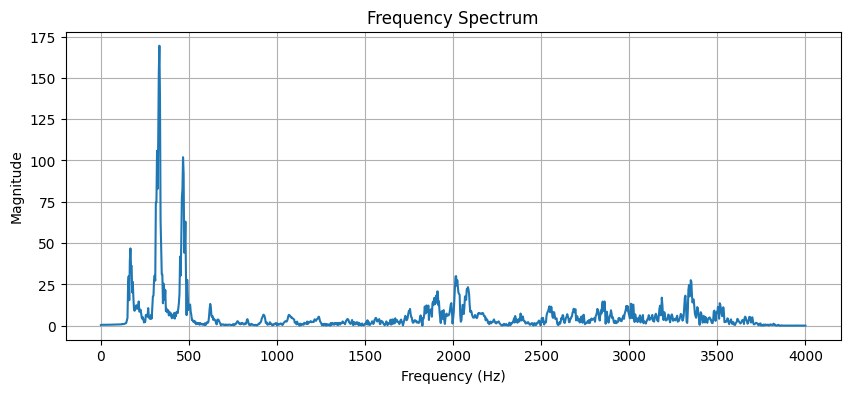

In [8]:
sample_rate, signal = load_audio(file_path)

print("Sample rate:", sample_rate)
print("Signal length:", len(signal))

freqs, magnitude = compute_fft(signal, sample_rate)

plot_spectrum(freqs, magnitude)

In [15]:
def zero_padding_fft_separate(signal, sample_rate):
    N = len(signal)
    N_padded = 4 * N

    # Original FFT
    freqs1 = np.fft.rfftfreq(N, d=1/sample_rate)
    mag1 = np.abs(np.fft.rfft(signal))

    # Zero-padded FFT
    freqs2 = np.fft.rfftfreq(N_padded, d=1/sample_rate)
    mag2 = np.abs(np.fft.rfft(signal, n=N_padded))

    # Plot 1: Original
    plt.figure(figsize=(10,4))
    plt.plot(freqs1, mag1)
    plt.title("Original Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

    # Plot 2: Zero-padded
    plt.figure(figsize=(10,4))
    plt.plot(freqs2, mag2)
    plt.title("Zero-Padded Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.xlim(300, 600)

    plt.show()

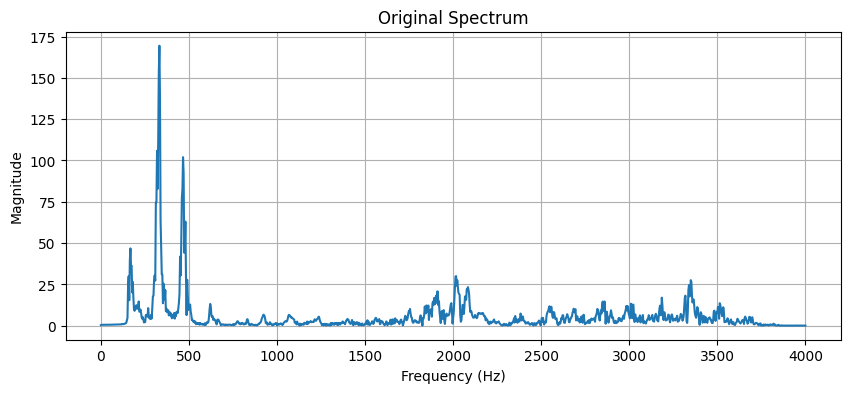

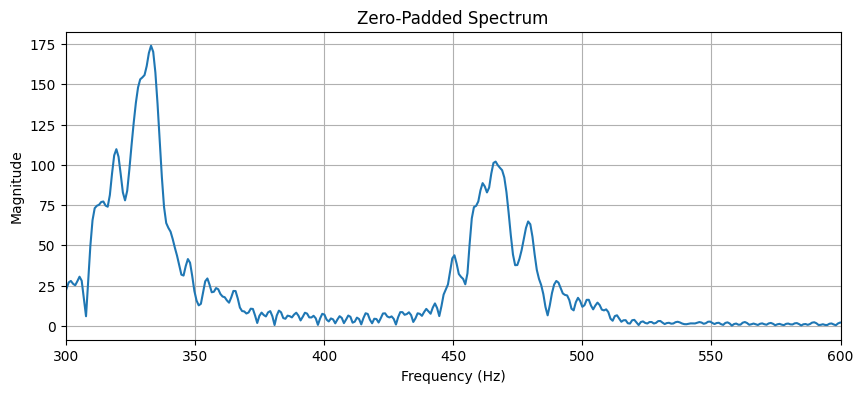

In [16]:
zero_padding_fft_separate(signal, sample_rate)

In [17]:
import numpy as np

def spectral_centroid(freqs, magnitude):
    """
    Compute spectral centroid.

    Parameters:
        freqs (np.ndarray): Frequency bins in Hz
        magnitude (np.ndarray): Magnitude spectrum

    Returns:
        float: Spectral centroid in Hz
    """
    if np.sum(magnitude) == 0:
        return 0.0
    return np.sum(freqs * magnitude) / np.sum(magnitude)


def spectral_bandwidth(freqs, magnitude, centroid=None):
    """
    Compute spectral bandwidth.

    Parameters:
        freqs (np.ndarray): Frequency bins in Hz
        magnitude (np.ndarray): Magnitude spectrum
        centroid (float or None): Precomputed centroid

    Returns:
        float: Spectral bandwidth in Hz
    """
    if np.sum(magnitude) == 0:
        return 0.0

    if centroid is None:
        centroid = spectral_centroid(freqs, magnitude)

    return np.sqrt(np.sum(((freqs - centroid) ** 2) * magnitude) / np.sum(magnitude))


def peak_frequency(freqs, magnitude):
    """
    Find the peak frequency.

    Parameters:
        freqs (np.ndarray): Frequency bins in Hz
        magnitude (np.ndarray): Magnitude spectrum

    Returns:
        float: Peak frequency in Hz
    """
    return freqs[np.argmax(magnitude)]

In [18]:
centroid = spectral_centroid(freqs, magnitude)
bandwidth = spectral_bandwidth(freqs, magnitude, centroid)
peak = peak_frequency(freqs, magnitude)

print("Spectral Centroid:", centroid, "Hz")
print("Spectral Bandwidth:", bandwidth, "Hz")
print("Peak Frequency:", peak, "Hz")

Spectral Centroid: 1566.826916535579 Hz
Spectral Bandwidth: 1189.6494089653186 Hz
Peak Frequency: 332.2147651006712 Hz


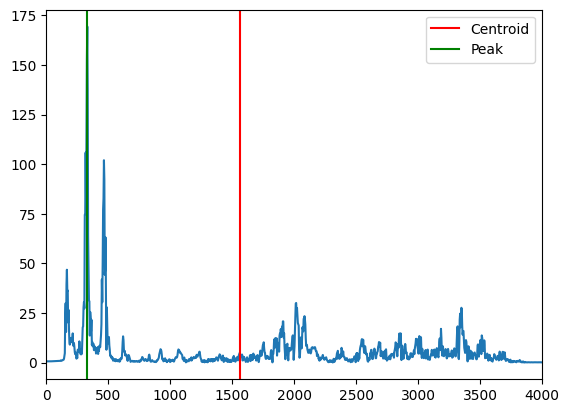

In [20]:
import os
import pandas as pd

def extract_features_from_all_files(folder_path):
    """
    Extract spectral features from all WAV files in a folder.

    Parameters:
        folder_path (str): Path to folder containing WAV files

    Returns:
        pd.DataFrame: Table of extracted features
    """
    rows = []

    for file_name in sorted(os.listdir(folder_path)):
        if not file_name.endswith(".wav"):
            continue

        file_path = os.path.join(folder_path, file_name)

        # Load audio using your existing function
        sample_rate, signal = load_audio(file_path)

        # Compute FFT using your existing function
        freqs, magnitude = compute_fft(signal, sample_rate)

        # Extract features using your existing functions
        centroid = spectral_centroid(freqs, magnitude)
        bandwidth = spectral_bandwidth(freqs, magnitude, centroid)
        peak = peak_frequency(freqs, magnitude)

        # Label is the first part before underscore, e.g. 0_george_0.wav -> 0
        digit = int(file_name.split("_")[0])

        rows.append({
            "file_name": file_name,
            "digit": digit,
            "sample_rate": sample_rate,
            "signal_length": len(signal),
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth,
            "peak_frequency": peak
        })

    df = pd.DataFrame(rows)
    return df

In [21]:
folder_path = "free-spoken-digit-dataset/recordings"
df_features = extract_features_from_all_files(folder_path)

print(df_features.head())
print("Number of files:", len(df_features))

         file_name  digit  sample_rate  signal_length  spectral_centroid  \
0   0_george_0.wav      0         8000           2384        1566.826917   
1   0_george_1.wav      0         8000           4727        1235.720690   
2  0_george_10.wav      0         8000           5958        1456.399662   
3  0_george_11.wav      0         8000           3661        1502.909773   
4  0_george_12.wav      0         8000           4050        1418.330723   

   spectral_bandwidth  peak_frequency  
0         1189.649409      332.214765  
1         1011.293896      318.172202  
2         1111.206429      302.114804  
3         1108.118366      489.483748  
4         1054.656296      318.024691  
Number of files: 3000


In [22]:
df_features.to_csv("dft_features.csv", index=False)
print("Saved as dft_features.csv")

Saved as dft_features.csv


In [23]:
df_features.groupby("digit")[["spectral_centroid", "spectral_bandwidth", "peak_frequency"]].mean()

,spectral_centroid,spectral_bandwidth,peak_frequency
digit,,,
0,1043.487504,956.232003,284.645116
1,970.526067,813.624912,356.809225
2,1077.310512,1061.429356,304.592759
3,1167.456883,1027.014488,292.746766
4,764.115905,678.291947,454.174178
5,1061.289118,795.298411,494.821413
6,1273.493176,1085.565261,366.801283
7,1105.816592,950.380692,419.661546
8,1388.437272,1111.147940,326.765384
